In [1]:
file_path = "C:/Users/da3ma/OneDrive/Desktop/Real_estate - Real_estate.csv"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(file_path)

In [4]:
df.head()

,Trans date,House age,Distance station,No of stores,Latitude,Longitude,House Price
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
df.describe()

,Trans date,House age,Distance station,No of stores,Latitude,Longitude,House Price
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [6]:
df.isnull().sum()

Trans date          0
House age           0
Distance station    0
No of stores        0
Latitude            0
Longitude           0
House Price         0
dtype: int64

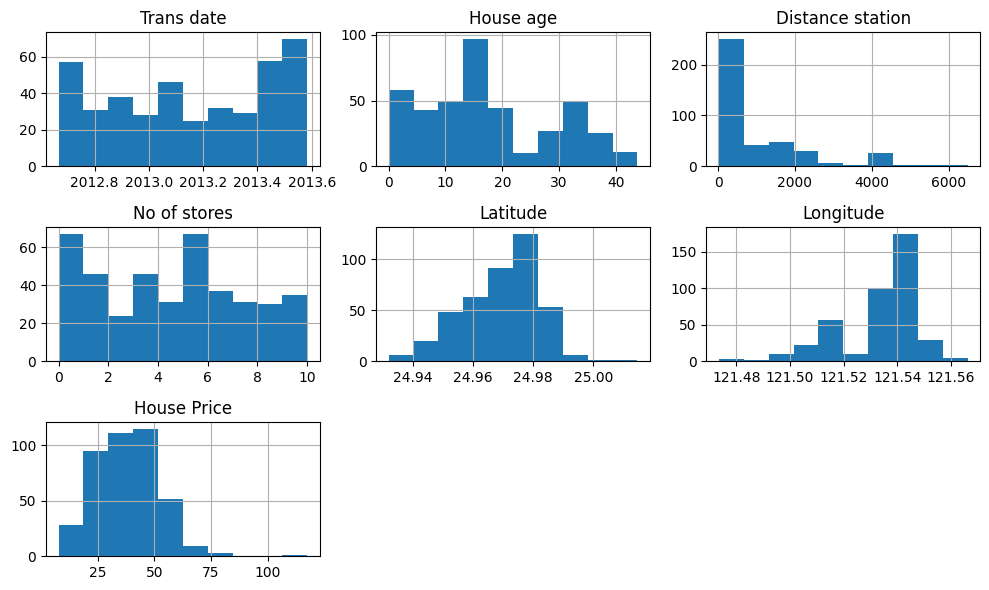

In [7]:
df.hist(figsize=(10,6))
plt.tight_layout()
plt.show()

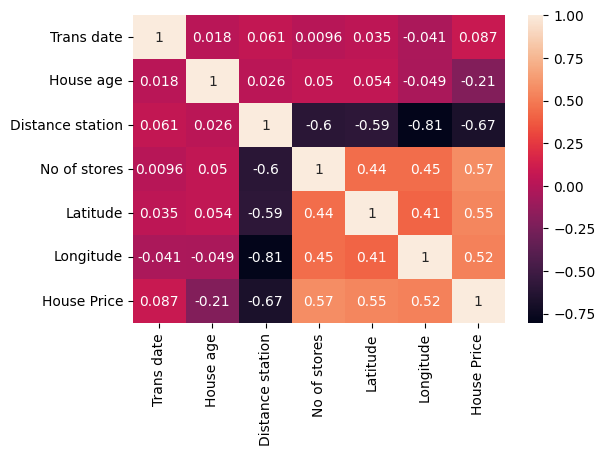

In [8]:
corr = df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.show()

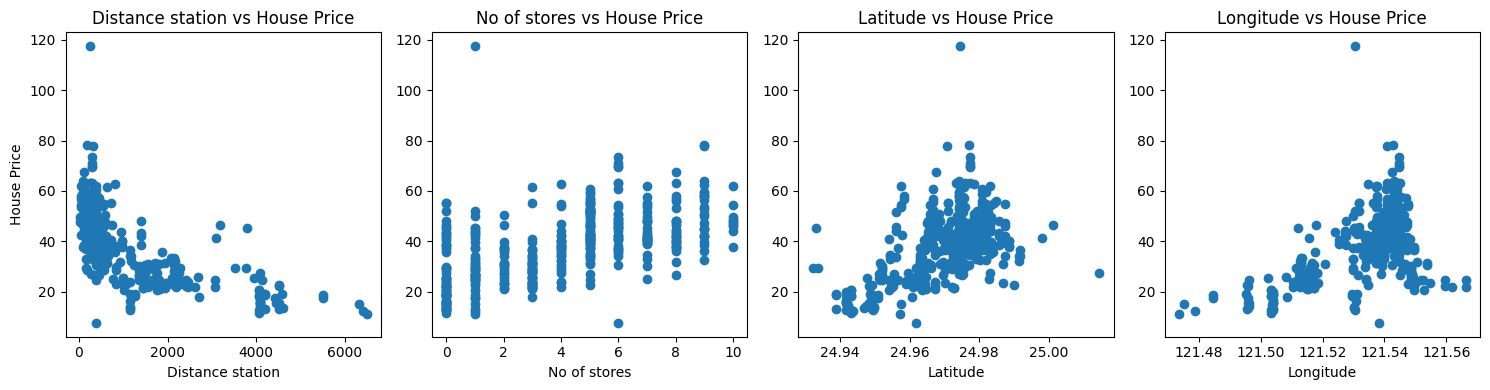

In [9]:
plt.figure(figsize=(15,4))


plt.subplot(1,4,1)
plt.scatter(df['Distance station'], df['House Price'])
plt.title('Distance station vs House Price')
plt.xlabel('Distance station')
plt.ylabel('House Price')

plt.subplot(1,4,2)
plt.scatter(df['No of stores'], df['House Price'])
plt.title('No of stores vs House Price')
plt.xlabel('No of stores')

plt.subplot(1,4,3)
plt.scatter(df['Latitude'], df['House Price'])
plt.title('Latitude vs House Price')
plt.xlabel('Latitude')

plt.subplot(1,4,4)
plt.scatter(df['Longitude'], df['House Price'])
plt.title('Longitude vs House Price')
plt.xlabel('Longitude')

plt.tight_layout()
plt.show()

In [10]:
lat_center = 24.975
long_center = 121.540

df['Distance_from_center'] = np.sqrt(
    np.square(df['Latitude'] - lat_center) + 
    np.square(df['Longitude'] - long_center)
)

print(df[['Latitude', 'Longitude', 'Distance_from_center']].head())

   Latitude  Longitude  Distance_from_center
0  24.98298  121.54024              0.007984
1  24.98034  121.53951              0.005362
2  24.98746  121.54391              0.013059
3  24.98746  121.54391              0.013059
4  24.97937  121.54245              0.005010


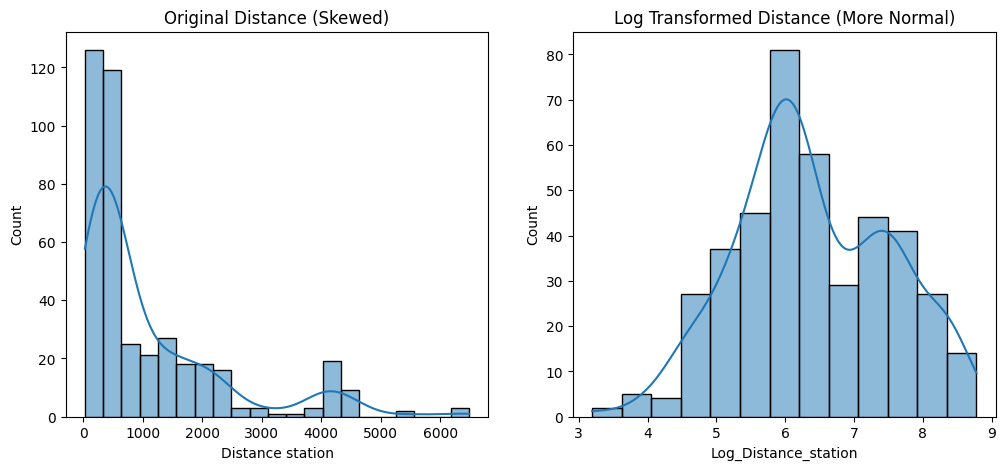

In [ ]:
df['Log_Distance_station'] = np.log1p(df['Distance station'])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Distance station'], kde=True)
plt.title('Original Distance (Skewed)')

plt.subplot(1, 2, 2)
sns.histplot(df['Log_Distance_station'], kde=True)
plt.title('Log Transformed Distance (More Normal)')

plt.show()

In [12]:
print(df.head())


   Trans date  House age  Distance station  No of stores  Latitude  Longitude  \
0    2012.917       32.0          84.87882            10  24.98298  121.54024   
1    2012.917       19.5         306.59470             9  24.98034  121.53951   
2    2013.583       13.3         561.98450             5  24.98746  121.54391   
3    2013.500       13.3         561.98450             5  24.98746  121.54391   
4    2012.833        5.0         390.56840             5  24.97937  121.54245   

   House Price  Distance_from_center  Log_Distance_station  
0         37.9              0.007984              4.452937  
1         42.2              0.005362              5.728783  
2         47.3              0.013059              6.333252  
3         54.8              0.013059              6.333252  
4         43.1              0.005010              5.970160  


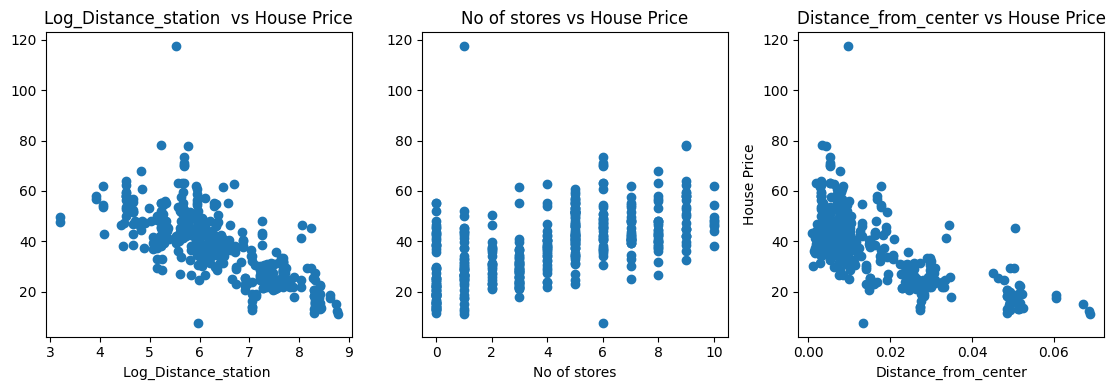

In [13]:
plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.scatter(df['Log_Distance_station'], df['House Price'])
plt.title('Log_Distance_station  vs House Price')
plt.xlabel('Log_Distance_station ')

plt.subplot(1,4,2)
plt.scatter(df['No of stores'], df['House Price'])
plt.title('No of stores vs House Price')
plt.xlabel('No of stores')

plt.subplot(1,4,3)
plt.scatter(df['Distance_from_center'], df['House Price'])
plt.title('Distance_from_center vs House Price')
plt.xlabel('Distance_from_center')
plt.ylabel('House Price')


plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

features = ['Trans date', 'House age', 'No of stores', 'Distance_from_center', 'Log_Distance_station']
X = df[features]
y = df['House Price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

regr = LinearRegression()
regr.fit(X_train, y_train)


regr_y_pred = regr.predict(X_test)


regr_mae = mean_absolute_error(y_test, regr_y_pred)
regr_r2 = r2_score(y_test, regr_y_pred)

print(f"Linear Regression - MAE: {regr_mae:.2f}")
print(f"Linear Regression - R2 Score: {regr_r2:.4f}")

Linear Regression - MAE: 4.48
Linear Regression - R2 Score: 0.7322


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest - MAE: {rf_mae:.2f}")
print(f"Random Forest - R2 Score: {rf_r2:.4f}")

Random Forest - MAE: 3.92
Random Forest - R2 Score: 0.8166



--- Comparison Table ---
               Model  MAE (Lower is better)  R2 Score (Higher is better)
0  Linear Regression               4.480447                     0.732246
1      Random Forest               3.922911                     0.816648


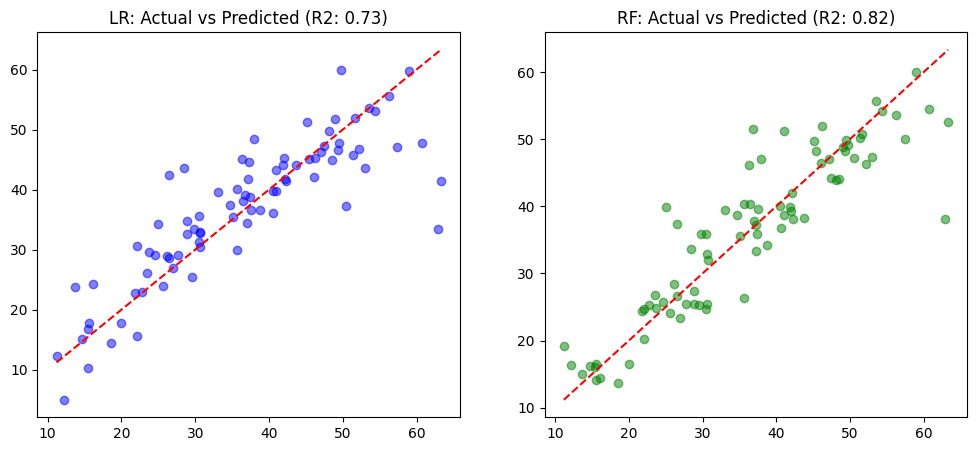

In [18]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE (Lower is better)': [regr_mae, rf_mae],
    'R2 Score (Higher is better)': [regr_r2, rf_r2]
})
print("\n--- Comparison Table ---")
print(results)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, regr_y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'LR: Actual vs Predicted (R2: {regr_r2:.2f})')

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_pred, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'RF: Actual vs Predicted (R2: {rf_r2:.2f})')

plt.show()